# Classificação de imagens usando redes neurais

Veremos como utilizar uma rede de classificação através da biblioteca timm (Pytorch Image Models)

## Carregamento e exploração da rede neural

In [1]:
import numpy as np
import timm

model_name = "convnextv2_atto"
# pretrained=True carrega o modelo com os pesos pré-treinados no ImageNet
model = timm.create_model(model_name, pretrained=True)
# Coloca o modelo em modo de avaliação
model.eval()

# Carrega as classes do ImageNet
classes = open("../../dados/imagenet_classes.txt").read().splitlines()
classes = np.array(classes)
print("Classes suportadas pelo modelo:")
print(classes)

Classes suportadas pelo modelo:
['tench' 'goldfish' 'great white shark' 'tiger shark' 'hammerhead'
 'electric ray' 'stingray' 'cock' 'hen' 'ostrich' 'brambling' 'goldfinch'
 'house finch' 'junco' 'indigo bunting' 'robin' 'bulbul' 'jay' 'magpie'
 'chickadee' 'water ouzel' 'kite' 'bald eagle' 'vulture' 'great grey owl'
 'European fire salamander' 'common newt' 'eft' 'spotted salamander'
 'axolotl' 'bullfrog' 'tree frog' 'tailed frog' 'loggerhead'
 'leatherback turtle' 'mud turtle' 'terrapin' 'box turtle' 'banded gecko'
 'common iguana' 'American chameleon' 'whiptail' 'agama' 'frilled lizard'
 'alligator lizard' 'Gila monster' 'green lizard' 'African chameleon'
 'Komodo dragon' 'African crocodile' 'American alligator' 'triceratops'
 'thunder snake' 'ringneck snake' 'hognose snake' 'green snake'
 'king snake' 'garter snake' 'water snake' 'vine snake' 'night snake'
 'boa constrictor' 'rock python' 'Indian cobra' 'green mamba' 'sea snake'
 'horned viper' 'diamondback' 'sidewinder' 'trilobite

Qualquer imagem passada ao modelo precisa primeiro ser pré-processada. Tipicamente, o pré-processamento envolve:

1. Converter a imagem do tipo pillow ou numpy para o tipo tensor do Pytorch
2. Converter a imagem para o tipo float
3. Redimensionar a imagem para um tamanho menor
4. Normalizar a imagem para que os valores de intensidade fiquem aproximadamente entre -1 e 1

A biblioteca timm permite carregar facilmente as funções de pré-processamento.

In [2]:
from timm.data.transforms_factory import create_transform

data_config = timm.data.resolve_data_config(model=model)
transforms = create_transform(**data_config)
print("Transformações de pré-processamento:")
print(transforms)

Transformações de pré-processamento:
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


## Aplicação do modelo

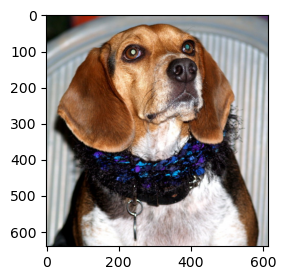

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

torch.backends.nnpack.enabled = False

root = Path("../../dados/dogs")
img_paths = list(root.iterdir())
img = Image.open(root / img_paths[0])

plt.imshow(img)

In [4]:
def apply_model(img, model, transforms):
    """Aplica a CNN pré-treinada na imagem e retorna a predição do modelo."""

    img_t = transforms(img)
    # O modelo trabalha com lotes de imagens, isto é, ele espera que a CNN seja aplicada em um 
    # conjunto de imagens ao invés de uma única imagem. Como estamos trabalhando apenas com uma 
    # imagem, criamos um lote contendo apenas uma imagem. 
    batch = img_t.unsqueeze(0)

    # Para aplicar a CNN na imagem, é importante utilizar o contexto "with torch.no_grad():" 
    # para evitar computações desnecessárias, mas não daria erro se não utilizássemos o contexto.
    with torch.no_grad():
        prediction = model(batch)

    prediction = prediction[0]
    
    return prediction

prediction = apply_model(img, model, transforms)
print("Predição do modelo:")
print(prediction.shape)

Predição do modelo:
torch.Size([1000])


A rede prevê 1000 valores. Esses valores são pontuações que o modelo associa a cada uma das 1000 classes do ImageNet. Podemos ordenar os valores do maior para o menor:

In [5]:
sorted_scores, sorted_indices = torch.sort(prediction, descending=True)
classes_sorted = classes[sorted_indices]

for i in range(5):
    print(f"{classes_sorted[i]}: {sorted_scores[i].item():.4f}")

beagle: 7.5738
Walker hound: 6.2262
bluetick: 5.2579
English foxhound: 4.2142
black-and-tan coonhound: 4.1724


A função softmax normaliza os valores de forma que eles sejam interpretados como probabilidade:

In [6]:
sorted_probs = torch.softmax(sorted_scores, dim=0)

for i in range(5):
    print(f"{classes_sorted[i]}: {sorted_probs[i].item():.4f}")

beagle: 0.4867
Walker hound: 0.1265
bluetick: 0.0480
English foxhound: 0.0169
black-and-tan coonhound: 0.0162


### Aplicação em diversas imagens

Vamos visualizar a previsão do modelo para algumas imagens. Para averiguar o grau de confiança do modelo, é útil mostrar a probabilidade da classe mais provável e comparar o valor com a segunda classe mais provável.

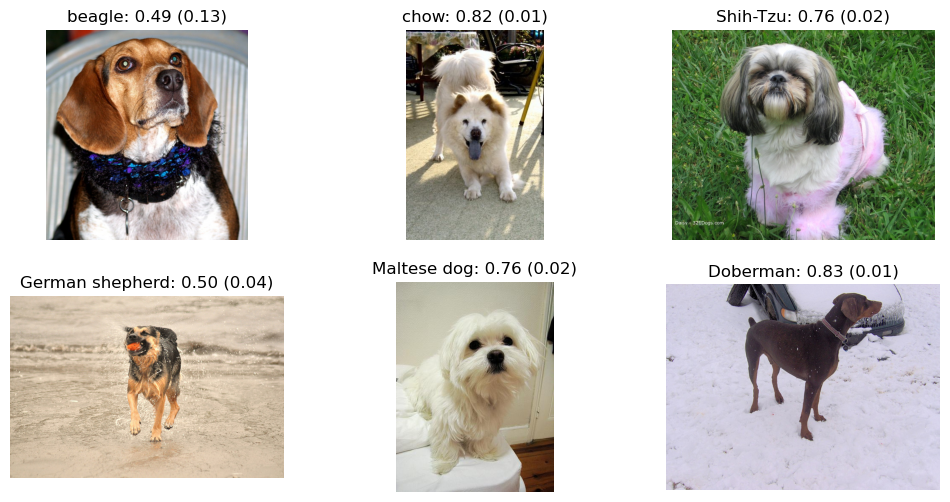

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for path, ax in zip(img_paths, axes):
    img = Image.open(root / path)   
    prediction = apply_model(img, model, transforms)
    probs = torch.softmax(prediction, dim=0)

    # Identifica as duas classes mais prováveis e suas respectivas probabilidades
    top2_probs, top2_indices = torch.topk(probs, k=2)
    class_name = classes[top2_indices[0]]
    prob_top1, prob_top2 = top2_probs
    
    ax.imshow(img)
    ax.axis("off")
    # Exibe o nome da classe mais provável e sua probabilidade, e entre parênteses a probabilidade 
    # da segunda classe mais provável
    ax.set_title(f"{class_name}: {prob_top1:.2f} ({prob_top2:.2f})")
plt.show()

## Uso do modelo como extrator de atributos

In [8]:
print("Camada final de classificação do modelo:")
model.head.fc

Camada final de classificação do modelo:


Linear(in_features=320, out_features=1000, bias=True)

A camada final do modelo recebe 320 valores e gera 1000 valores de pontuação para as 1000 classes do ImageNet. Podemos carregar o modelo sem a camada final de classificação:

In [10]:
model = timm.create_model(model_name, pretrained=True, num_classes=0)
features = apply_model(img, model, transforms)
print("Atributos extraídos pela CNN:")
print(features.shape)

Atributos extraídos pela CNN:
torch.Size([320])


Esse modelo extrai 320 valores que são utilizados para classificar milhões de imagens em 1000 categorias! Portanto, esses 320 valores fornecem muita informação sobre o conteúdo da imagem.